Matplotlib is building the font cache; this may take a moment.


median_RAQI           0.489
%_time_high_RAQI     25.714
avg_noise_RMS         4.339
spikes_per_min      102.500
dtype: float64


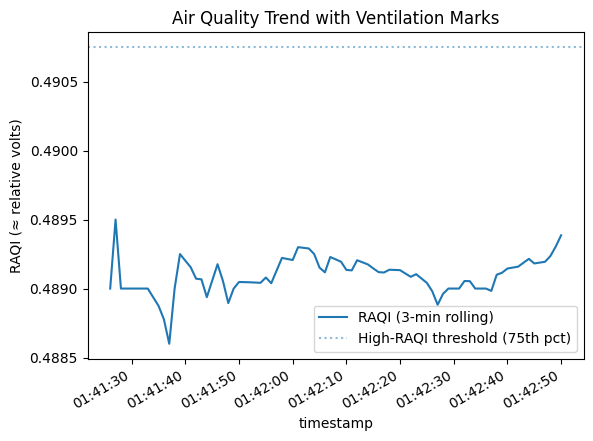

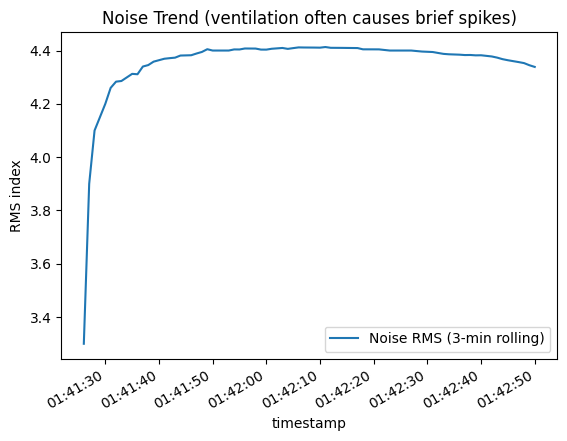

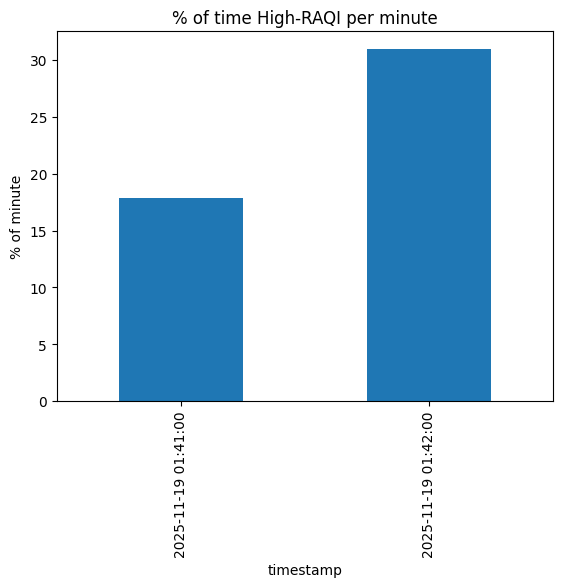

In [1]:
# analyze.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Load and tidy
p = sorted(Path("logs").glob("sensors_*.csv"))[-1]  # latest file
df = pd.read_csv(p, parse_dates=["timestamp"])
df = df.sort_values("timestamp").set_index("timestamp")

# 2) Smooth and engineer features
df["raqi_ma3"]   = df["raqi_volt"].rolling("180s").mean()
df["noise_ma3"]  = df["noise_rms"].rolling("180s").mean()
df["spikes_1min"]= df["noise_spikes"].rolling("60s").sum()
hi_thresh = df["raqi_volt"].quantile(0.75)

# 3) Simple KPIs
kpi = {
    "median_RAQI": df["raqi_volt"].median(),
    "%_time_high_RAQI": (df["raqi_volt"] > hi_thresh).mean()*100,
    "avg_noise_RMS": df["noise_rms"].mean(),
    "spikes_per_min": df["noise_spikes"].resample("1min").sum().mean()
}
print(pd.Series(kpi).round(3))

# 4) Detect ventilation bursts heuristically (noise jump + RAQI drop)
raqi_drop = df["raqi_ma3"].diff().rolling(10).sum()   # ~10 s window
vents = (df["spikes_1min"] > df["spikes_1min"].median()*1.5) & (raqi_drop < -0.02)
vent_marks = df.index[vents.fillna(False)]

# 5) Plots
plt.figure()
df["raqi_ma3"].plot(label="RAQI (3-min rolling)")
for t in vent_marks: plt.axvline(t, ls="--", alpha=0.3)
plt.axhline(hi_thresh, ls=":", alpha=0.5, label="High-RAQI threshold (75th pct)")
plt.title("Air Quality Trend with Ventilation Marks")
plt.ylabel("RAQI (≈ relative volts)"); plt.legend()

plt.figure()
df["noise_ma3"].plot(label="Noise RMS (3-min rolling)")
for t in vent_marks: plt.axvline(t, ls="--", alpha=0.3)
plt.title("Noise Trend (ventilation often causes brief spikes)")
plt.ylabel("RMS index"); plt.legend()

plt.figure()
(df["raqi_volt"] > hi_thresh).resample("1min").mean().mul(100).plot(kind="bar")
plt.title("% of time High-RAQI per minute"); plt.ylabel("% of minute")

plt.show()